In [1]:
import secrets
from typing import Optional
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
import torchopt
from torch.utils.data import TensorDataset, DataLoader

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R

from sklearn.datasets import load_wine, load_breast_cancer, load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.set_style("ticks")

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed: 283199255


### Data utils

In [ ]:
# Quelques alias pratiques (modifie/complète au besoin)
UCI_NAME_TO_ID = {
    "credit_default": 350,  # Default of Credit Card Clients
    "german_credit": 144,  # Statlog German Credit
    "polish_bankruptcy": 365,  # Polish Companies Bankruptcy
    # "adult": 2,                  # Adult (si besoin)
    "Yeast": 110,
}


def _ensure_numpy_X_y(X, y):
    # X peut être DataFrame ou ndarray ; y peut être Series/ndarray/obj
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    if isinstance(y, (pd.Series, pd.DataFrame)):
        y = y.to_numpy().ravel()

    # Encode labels non-numériques (ex: 'good'/'bad')
    if y.dtype.kind not in "iu":  # pas int/uint
        le = LabelEncoder()
        y = le.fit_transform(y.astype(str))
    return X, y.astype(np.int64, copy=False)


def load_uci_new(
    dataset="wine",
    test_size=0.2,
    val_size=0.2,
    batch_size=256,
    standardize=True,
    impute_missing=True,
    impute_strategy="median",
    random_state=0,
    uci_id=None,
):
    """
    Charge un dataset soit via scikit-learn (wine/iris/breast_cancer/load_digits),
    soit via UCI (ucimlrepo) si `uci_id` est fourni ou si `dataset` est dans UCI_NAME_TO_ID.
    Renvoie (train_loader, val_loader, test_loader, meta) avec le même format TensorDataset
    que ton code (X, y, y, zeros).
    """
    # --- 1) Sélection de la source des données ---
    if dataset in {"wine", "iris", "breast_cancer", "load_digits"} and uci_id is None:
        if dataset == "wine":
            data = load_wine()
        elif dataset == "iris":
            data = load_iris()
        elif dataset == "breast_cancer":
            data = load_breast_cancer()
        elif dataset == "load_digits":
            data = load_digits()
        X, y = data.data, data.target

    else:
        # UCI via ucimlrepo
        if uci_id is None:
            # essaie de mapper un alias connu, sinon lève une erreur claire
            if dataset in UCI_NAME_TO_ID:
                uci_id = UCI_NAME_TO_ID[dataset]
            else:
                raise ValueError(
                    f"Unknown dataset '{dataset}'. "
                    f"Use one of {{'wine','iris','breast_cancer','load_digits'}} "
                    f"or provide a valid UCI id via `uci_id`."
                )
        ds = fetch_ucirepo(id=uci_id)
        X = ds.data.features
        y = ds.data.targets
        if isinstance(y, pd.DataFrame) and y.shape[1] > 1:
            y = y.iloc[:, 0]

        X, y = _ensure_numpy_X_y(X, y)

    if impute_missing:
        imp = SimpleImputer(strategy=impute_strategy)
        X = imp.fit_transform(X)

    if standardize:
        scaler = StandardScaler().fit(X)
        X = scaler.transform(X)

    X_tr, X_tt, y_tr, y_tt = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=random_state
    )

    X_tr = torch.tensor(X_tr, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    X_tt = torch.tensor(X_tt, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)
    y_tt = torch.tensor(y_tt, dtype=torch.long)

    tr_loader = DataLoader(
        TensorDataset(X_tr, y_tr, y_tr, torch.zeros_like(y_tr)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(X_val, y_val, y_val, torch.zeros_like(y_val)),
        batch_size=batch_size,
        shuffle=False,
    )
    tst_loader = DataLoader(
        TensorDataset(X_tt, y_tt, y_tt, torch.zeros_like(y_tt)),
        batch_size=batch_size,
        shuffle=False,
    )

    meta = {"input_dim": X.shape[1], "num_classes": int(np.unique(y).size)}
    return tr_loader, val_loader, tst_loader, meta


def load_uci(
    dataset="wine", test_size=0.2, val_size=0.2, batch_size=256, standardize=True
):
    if dataset == "wine":
        data = load_wine()
    elif dataset == "iris":
        data = load_iris()
    elif dataset == "breast_cancer":
        data = load_breast_cancer()
    elif dataset == "load_digits":
        data = load_digits()
    else:
        raise ValueError(f"Unknown dataset: {dataset}")
    X, y = data.data, data.target
    if standardize:
        scaler = StandardScaler().fit(X)
        X = scaler.transform(X)

    # train / (val+test)
    X_tr, X_tt, y_tr, y_tt = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=0
    )
    # split val from train
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=0
    )
    # conversion en tensor type pour le donner au dataloader
    X_tr = torch.tensor(X_tr, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    X_tt = torch.tensor(X_tt, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)
    y_tt = torch.tensor(y_tt, dtype=torch.long)

    tr_loader = DataLoader(
        TensorDataset(X_tr, y_tr, y_tr, torch.zeros_like(y_tr)),
        batch_size=batch_size if batch_size > 0 else len(X_tr),
        shuffle=True,
    )
    # on ne shuffle pas la val et le test
    val_loader = DataLoader(
        TensorDataset(X_val, y_val, y_val, torch.zeros_like(y_val)),
        batch_size=len(X_val),
        shuffle=False,
    )
    tst_loader = DataLoader(
        TensorDataset(X_tt, y_tt, y_tt, torch.zeros_like(y_tt)),
        batch_size=batch_size if batch_size > 0 else len(X_tt),
        shuffle=False,
    )

    meta = {"input_dim": X.shape[1], "num_classes": len(np.unique(y))}
    return tr_loader, val_loader, tst_loader, meta

### Torchopt

#### Functional API

In [3]:
# -----------------------
# Helper: make functional params with grad
# -----------------------
def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization_implicit(
    train_loader,
    val_loader,
    input_dim: int,
    num_classes: int,
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
    entropy_weight: float = 1.0,
    n_generations: int = 5,
    outer_scheduler_patience: int = 0,
    early_stopping_patience: int = 0,
    reward_network: Optional[torch.nn.Module] = None,
):
    # reward
    reward_network = reward_network.to(device)
    reward_model, reward_params = make_functional_with_grads(reward_network)

    # reward loss: nll
    nll_loss = L.FuncNLL_Classification()

    # Tracking
    train_accuracy = []
    val_accuracy = []
    outer_losses = []
    val_outer_losses = []
    inner_losses = []
    inner_rewards = []
    # Initialize tracking dictionaries for reward network parameters
    U_coeff = {}
    U_coeff_grad = {}
    # Get parameter names and shapes from reward network
    for name, param in reward_network.named_parameters():
        if param.requires_grad is True:
            if param.dim() == 2:  # Matrix parameter
                rows, cols = param.shape
                for i in range(rows):
                    for j in range(cols):
                        key = f"{name}_{i + 1}_{j + 1}"
                        U_coeff[key] = []
                        U_coeff_grad[key] = []
            elif param.dim() == 1:  # Vector parameter
                for i in range(param.shape[0]):
                    key = f"{name}_{i + 1}"
                    U_coeff[key] = []
                    U_coeff_grad[key] = []
            else:  # Scalar parameter
                U_coeff[name] = []
                U_coeff_grad[name] = []

    # Inner-loop objective function
    # The optimality function: grad(inner_objective)
    def inner_objective(policy_params, reward_params, X, y, policy_model, reward_model):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncOneHotRewardNetwork(
            reward_model=reward_model,
            reward_params=reward_params_dict,
            num_classes=num_classes,
        )

        # policy loss
        pg_loss = L.FuncPO_Entropy_Classification(
            reward_fn=reward_fn,
            n_generations=n_generations,
            use_rsample=False,
            reward_transform="none",
            entropy_weight=entropy_weight,
        )

        # Reconstruct params dict (for functional_call)
        policy_params_dict = dict(
            zip(dict(policy_model.named_parameters()).keys(), policy_params)
        )
        loss, _ = pg_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
            reward_model=reward_model,
            reward_params=reward_params_dict,
        )
        return loss

    # Optimality Condition is: the gradient w.r.t inner-loop optimal params is 0 (we achieve so by
    # specifying argnums=0 in functorch.grad) the argnums=1 specify which meta-parameter we want to
    # backpropogate, in this case we want to backpropogate to the initial parameters so we set it as 1.
    # You can also set argnums as (1, 2) if you want to backpropogate through multiple meta-parameters

    # Here we pass argnums=1 to the custom_root. That means we want to compute the gradient of
    # optimal_params w.r.t. the 1-indexed argument in inner_solver, i.e., params.
    # torchopt.linear_solve.solve_normal_cg specify that we use the conjugate gradient based linear solver
    @torchopt.diff.implicit.custom_root(
        torch.func.grad(inner_objective, argnums=0),  # optimality function
        argnums=1,
        solve=torchopt.linear_solve.solve_normal_cg(maxiter=1, atol=1e-6),
        # solve=torchopt.linear_solve.solve_inv(ns=True, maxiter=100, alpha=0.1),
    )
    def inner_solver(policy_params, reward_params, X, y, policy_model, reward_model):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncOneHotRewardNetwork(
            reward_model=reward_model,
            reward_params=reward_params_dict,
            num_classes=num_classes,
        )

        # policy loss
        pg_loss = L.FuncPO_Entropy_Classification(
            reward_fn=reward_fn,
            n_generations=n_generations,
            use_rsample=False,
            reward_transform="none",
            entropy_weight=entropy_weight,
        )

        def inner_loss_fn(policy_params, X, y):
            # Reconstruct params dict (for functional_call)
            policy_params_dict = dict(
                zip(dict(policy_model.named_parameters()).keys(), policy_params)
            )
            loss, _ = pg_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X,
                y=y,
                reward_model=reward_model,
                reward_params=reward_params_dict,
            )
            return loss

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.adam(lr=inner_lr)  # , momentum=0.9)  # , eps=1e-8)
        inner_opt_state = inner_optimizer.init(policy_params)

        # Inner loop with torchopt
        inner_losses_per_iter = []
        inner_rewards_per_iter = []
        for inner_step in range(n_inner_epochs):
            # Compute gradients and update
            grads = torch.func.grad(inner_loss_fn)(
                policy_params,
                X,
                y,
            )
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
            updates, inner_opt_state = inner_optimizer.update(
                grads, inner_opt_state, inplace=False
            )
            policy_params = torchopt.apply_updates(
                policy_params, updates, inplace=False
            )

            # Track loss
            with torch.no_grad():
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )
                inner_loss, metrics = pg_loss.compute_loss(
                    policy_model,
                    policy_params_dict,
                    X,
                    y,
                    reward_model=reward_model,
                    reward_params=reward_params_dict,
                )
                inner_losses_per_iter.append(float(inner_loss))
                inner_rewards_per_iter.append(metrics["reward_mean"])
        inner_losses.append(inner_losses_per_iter)
        inner_rewards.append(inner_rewards_per_iter)

        return tuple(policy_params)

    def outer_loss_fn(
        reward_params, policy_params, X, y, X_val, y_val, policy_model, reward_model
    ):
        policy_params = inner_solver(
            policy_params, reward_params, X, y, policy_model, reward_model
        )

        policy_params_dict = dict(
            zip(dict(policy_model.named_parameters()).keys(), policy_params)
        )

        # outer loss
        loss, train_metrics = nll_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
        )

        # Validation loss
        with torch.no_grad():
            val_loss, val_metrics = nll_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X_val,
                y=y_val,
            )
        return loss, val_loss, train_metrics["accuracy"], val_metrics["accuracy"]

    # Learning rate scheduler parameters
    factor = 0.75
    min_lr = 1e-6
    s_patience_counter = 0
    current_outer_lr = outer_lr

    es_patience_counter = 0
    best_val_loss = float("inf")
    best_reward_params = None

    for outer_epoch in tqdm(range(n_outer_epochs), desc="Outer Epochs"):
        # -----------------------
        # Outer loop: update reward params
        # -----------------------

        # Reset reward params gradient
        reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

        # reward optimizer with current learning rate
        outer_optimizer = torchopt.adam(lr=current_outer_lr)
        outer_opt_state = outer_optimizer.init(reward_params)

        # Reset policy each outer iteration
        policy = Policy.MulticlassLogisticRegression(input_dim, num_classes).to(device)
        policy_model, policy_params = make_functional_with_grads(policy)

        # Process batches for outer loop
        epoch_outer_losses = []
        epoch_val_losses = []
        epoch_train_accuracies = []
        epoch_val_accuracies = []

        accumulated_grads = None
        num_batches = 0

        # Create iterators for train and validation loaders
        val_iter = iter(val_loader)

        for batch_idx, (X_train_batch, y_train_batch, _, _) in enumerate(train_loader):
            X_train_batch = X_train_batch.to(device)
            y_train_batch = y_train_batch.to(device)

            # Get validation batch (cycle through val_loader if needed)
            try:
                X_val_batch, y_val_batch, _, _ = next(val_iter)
            except StopIteration:
                val_iter = iter(val_loader)
                X_val_batch, y_val_batch, _, _ = next(val_iter)

            X_val_batch = X_val_batch.to(device)
            y_val_batch = y_val_batch.to(device)

            # Compute gradients and losses for this batch
            loss, val_loss, train_acc, val_acc = outer_loss_fn(
                reward_params,
                policy_params,
                X_train_batch,
                y_train_batch,
                X_val_batch,
                y_val_batch,
                policy_model,
                reward_model,
            )

            epoch_outer_losses.append(float(loss))
            epoch_val_losses.append(float(val_loss))
            epoch_train_accuracies.append(float(train_acc))
            epoch_val_accuracies.append(float(val_acc))

            grads = torch.autograd.grad(loss, reward_params, create_graph=True)
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -10.0, 10.0) for g in grads]

            # Accumulate gradients
            if accumulated_grads is None:
                accumulated_grads = [g.clone() for g in grads]
            else:
                for i, g in enumerate(grads):
                    accumulated_grads[i] += g

            num_batches += 1

        # Average accumulated gradients
        accumulated_grads = [g / num_batches for g in accumulated_grads]

        # Update parameters with averaged gradients
        updates, outer_opt_state = outer_optimizer.update(
            accumulated_grads, outer_opt_state, inplace=False
        )
        reward_params = torchopt.apply_updates(reward_params, updates)

        # Store epoch averages
        avg_outer_loss = sum(epoch_outer_losses) / len(epoch_outer_losses)
        avg_val_loss = sum(epoch_val_losses) / len(epoch_val_losses)
        avg_train_acc = sum(epoch_train_accuracies) / len(epoch_train_accuracies)
        avg_val_acc = sum(epoch_val_accuracies) / len(epoch_val_accuracies)

        outer_losses.append(avg_outer_loss)
        val_outer_losses.append(avg_val_loss)
        train_accuracy.append(avg_train_acc)
        val_accuracy.append(avg_val_acc)

        # Early stopping: check if current validation loss is the best
        if early_stopping_patience:
            current_val_loss = avg_val_loss
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_reward_params = [p.detach().clone() for p in reward_params]
                es_patience_counter = 0
            else:
                es_patience_counter += 1
                reward_params = [p.detach().clone() for p in best_reward_params]
                if es_patience_counter >= early_stopping_patience:
                    print(f"Early stopping at outer epoch {outer_epoch}")
                    break

        if outer_scheduler_patience:
            current_val_loss = avg_val_loss
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                s_patience_counter = 0
            else:
                s_patience_counter += 1
            if (
                s_patience_counter >= outer_scheduler_patience
                and current_outer_lr > min_lr
            ):
                current_outer_lr = max(current_outer_lr * factor, min_lr)

        # Track all reward network parameters
        param_idx = 0
        for name, param in reward_network.named_parameters():
            if param.requires_grad is True:
                if param.dim() == 2:  # Matrix parameter
                    rows, cols = param.shape
                    for i in range(rows):
                        for j in range(cols):
                            key = f"{name}_{i + 1}_{j + 1}"
                            U_coeff[key].append(reward_params[param_idx][i, j].item())
                            U_coeff_grad[key].append(
                                accumulated_grads[param_idx][i, j].item()
                            )
                elif param.dim() == 1:  # Vector parameter
                    for i in range(param.shape[0]):
                        key = f"{name}_{i + 1}"
                        U_coeff[key].append(reward_params[param_idx][i].item())
                        U_coeff_grad[key].append(accumulated_grads[param_idx][i].item())
                else:  # Scalar parameter
                    U_coeff[name].append(reward_params[param_idx].item())
                    U_coeff_grad[name].append(accumulated_grads[param_idx].item())
            param_idx += 1

    return (
        train_accuracy,
        val_accuracy,
        outer_losses,
        val_outer_losses,
        inner_losses,
        inner_rewards,
        U_coeff,
        U_coeff_grad,
    )

In [18]:
# PG
entropy_weight: float = 21
n_generations: int = 5

# Data
batch_size: int = 128
dataset_name = "Yeast"
train_loader, val_loader, _, meta = load_uci_new(
    dataset=dataset_name,
    batch_size=batch_size,
    standardize=True,
    test_size=0.02,
    val_size=0.48,
)
num_classes = meta["num_classes"]
input_dim = meta["input_dim"]

# Reward
reward_init_param: float = 1.0
reward_use_softplus: bool = False
reward_network = RM.RewardMLPMahalanobisDiag(
    input_dim=num_classes,
    init_param=reward_init_param,
    use_softplus=reward_use_softplus,
)
# reward_network = RM.RewardMLPMahalanobis(
#     output_dim, is_diagonal=False, init_scale=reward_init_param
# )

n_outer_epochs: int = 1
n_inner_epochs: int = 300

inner_lr: float = 0.04
outer_lr: float = 1e-2
outer_scheduler_patience: int = 0
early_stopping_patience: int = 0

device: str = "cuda:0"

# Experiment parameters
max_repetitions = 3
max_tolerated_crashes = 10

print(f"data size train: {len(train_loader.dataset)}, val: {len(val_loader.dataset)}")

data size train: 756, val: 698


In [19]:
# Storage for all runs
all_train_accuracies = []
all_val_accuracies = []
all_outer_losses = []
all_val_outer_losses = []
all_inner_losses = []
all_inner_rewards = []
all_U_coeff = []
all_U_coeff_grad = []

successful_runs = 0
crashes = 0

for rep in range(max_repetitions):
    if crashes >= max_tolerated_crashes:
        print(
            f"Maximum tolerated crashes ({max_tolerated_crashes}) reached. Stopping experiments."
        )
        break

    try:
        print(f"Running experiment {rep + 1}/{max_repetitions}...")

        # Run the bilevel optimization
        (
            train_accuracy,
            val_accuracy,
            outer_losses,
            val_outer_losses,
            inner_losses,
            inner_rewards,
            U_coeff,
            U_coeff_grad,
        ) = run_bilevel_optimization_implicit(
            train_loader=train_loader,
            val_loader=val_loader,
            num_classes=num_classes,
            input_dim=input_dim,
            n_outer_epochs=n_outer_epochs,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_network=reward_network,
        )

        # Store results
        all_train_accuracies.append(train_accuracy)
        all_val_accuracies.append(val_accuracy)
        all_outer_losses.append(outer_losses)
        all_val_outer_losses.append(val_outer_losses)
        all_inner_losses.append(inner_losses)
        all_inner_rewards.append(inner_rewards)
        all_U_coeff.append(U_coeff)
        all_U_coeff_grad.append(U_coeff_grad)

        successful_runs += 1
        print(f"Experiment {rep + 1} completed successfully.")

    except Exception as e:
        crashes += 1
        print(f"Experiment {rep + 1} crashed: {str(e)}")
        print(f"Crashes so far: {crashes}/{max_tolerated_crashes}")
        continue

print(f"Completed {successful_runs} successful runs out of {max_repetitions} attempts.")

# Convert to numpy arrays for easier computation
all_train_accuracies = np.array(all_train_accuracies)
all_val_accuracies = np.array(all_val_accuracies)
all_outer_losses = np.array(all_outer_losses)
all_val_outer_losses = np.array(all_val_outer_losses)


# Process U_coeff and U_coeff_grad dictionaries
# Extract parameter names from first successful run
param_names = list(all_U_coeff[0].keys())

# Convert dictionary data to arrays for each parameter
U_coeff_arrays = {}
U_coeff_grad_arrays = {}

for param_name in param_names:
    # Extract data for this parameter across all runs
    U_coeff_data = [run_data[param_name] for run_data in all_U_coeff]
    U_coeff_grad_data = [run_data[param_name] for run_data in all_U_coeff_grad]

    U_coeff_arrays[param_name] = np.array(U_coeff_data)
    U_coeff_grad_arrays[param_name] = np.array(U_coeff_grad_data)

# Flatten inner rewards for averaging
all_inner_rewards_flat = []
for run in all_inner_rewards:
    flat_rewards = []
    for outer_epoch in run:
        flat_rewards.extend(outer_epoch)
    all_inner_rewards_flat.append(flat_rewards)
all_inner_rewards_flat = np.array(all_inner_rewards_flat)

# Compute statistics
train_accuracies_mean = np.mean(all_train_accuracies, axis=0)
train_accuracies_std = np.std(all_train_accuracies, axis=0)
train_accuracies_se = train_accuracies_std / np.sqrt(successful_runs)

val_accuracies_mean = np.mean(all_val_accuracies, axis=0)
val_accuracies_std = np.std(all_val_accuracies, axis=0)
val_accuracies_se = val_accuracies_std / np.sqrt(successful_runs)

outer_losses_mean = np.mean(all_outer_losses, axis=0)
outer_losses_std = np.std(all_outer_losses, axis=0)
outer_losses_se = outer_losses_std / np.sqrt(successful_runs)

val_outer_losses_mean = np.mean(all_val_outer_losses, axis=0)
val_outer_losses_std = np.std(all_val_outer_losses, axis=0)
val_outer_losses_se = val_outer_losses_std / np.sqrt(successful_runs)

# Compute statistics for U_coeff and U_coeff_grad for each parameter
U_coeff_mean = {}
U_coeff_std = {}
U_coeff_se = {}
U_coeff_grad_mean = {}
U_coeff_grad_std = {}
U_coeff_grad_se = {}

for param_name in param_names:
    U_coeff_mean[param_name] = np.mean(U_coeff_arrays[param_name], axis=0)
    U_coeff_std[param_name] = np.std(U_coeff_arrays[param_name], axis=0)
    U_coeff_se[param_name] = U_coeff_std[param_name] / np.sqrt(successful_runs)

    U_coeff_grad_mean[param_name] = np.mean(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_std[param_name] = np.std(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_se[param_name] = U_coeff_grad_std[param_name] / np.sqrt(
        successful_runs
    )

inner_rewards_mean = np.mean(all_inner_rewards_flat, axis=0)
inner_rewards_std = np.std(all_inner_rewards_flat, axis=0)
inner_rewards_se = inner_rewards_std / np.sqrt(successful_runs)

Running experiment 1/3...


Outer Epochs:   0%|          | 0/1 [00:00<?, ?it/s]/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/torchopt/diff/implicit/decorator.py:123: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vjp` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.vjp` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  _, optimality_cond_vjp_fn, *_ = functorch.vjp(optimality_cond, solution)
/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/torchopt/linear_solve/utils.py:49: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vjp` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.vjp` instead; see the PyTorch 2.0 release not

Experiment 1 completed successfully.
Running experiment 2/3...


Outer Epochs: 100%|██████████| 1/1 [00:06<00:00,  6.32s/it]


Experiment 2 completed successfully.
Running experiment 3/3...


Outer Epochs: 100%|██████████| 1/1 [00:08<00:00,  8.00s/it]

Experiment 3 completed successfully.
Completed 3 successful runs out of 3 attempts.


val losses: [0.35938997]
val losses: [2.28758964]
param_1: [1.00999987]


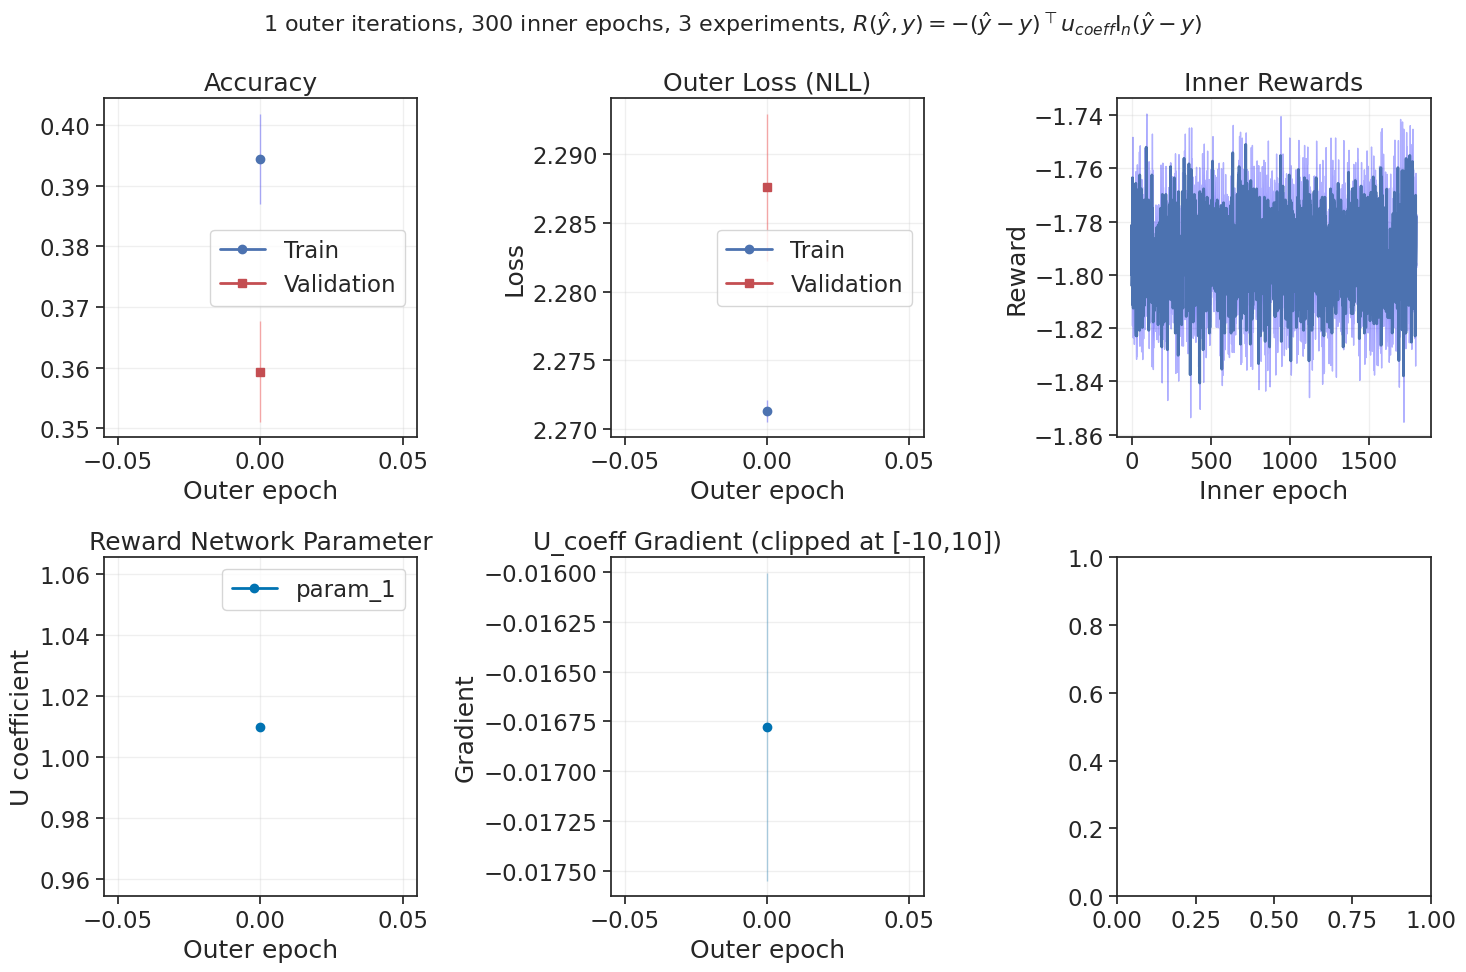

In [20]:
# Plot results with error bars
fig, ((ax0, ax1, ax2), (ax3, ax4, ax5)) = plt.subplots(2, 3, figsize=(15, 10))

# Plot accuracies (train and validation)
epochs_acc = range(len(train_accuracies_mean))
ax0.plot(
    epochs_acc, train_accuracies_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax0.fill_between(
    epochs_acc,
    train_accuracies_mean - train_accuracies_se,
    train_accuracies_mean + train_accuracies_se,
    alpha=0.3,
    color="blue",
)
ax0.plot(
    epochs_acc,
    val_accuracies_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
print(f"val losses: {val_accuracies_mean[-5:]}")
ax0.fill_between(
    epochs_acc,
    val_accuracies_mean - val_accuracies_se,
    val_accuracies_mean + val_accuracies_se,
    alpha=0.3,
    color="red",
)
ax0.set_xlabel("Outer epoch")
ax0.set_title("Accuracy")
ax0.legend()
ax0.grid(True, alpha=0.3)

# Plot outer losses (train and validation)
epochs_outer = range(len(outer_losses_mean))
ax1.plot(
    epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.plot(
    epochs_outer,
    val_outer_losses_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
print(f"val losses: {val_outer_losses_mean[-5:]}")
ax1.fill_between(
    epochs_outer,
    val_outer_losses_mean - val_outer_losses_se,
    val_outer_losses_mean + val_outer_losses_se,
    alpha=0.3,
    color="red",
)
ax1.set_xlabel("Outer epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Outer Loss (NLL)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    if i * n_inner_epochs < len(epochs_inner):
        ax2.axvline(
            x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3
        )

ax2.set_xlabel("Inner epoch")
ax2.set_ylabel("Reward")
ax2.set_title("Inner Rewards")
ax2.grid(True, alpha=0.3)
# Set integer ticks for x-axis
# ax2.set_xticks(range(0, len(epochs_inner), max(1, len(epochs_inner)//10)))

# Define colors from seaborn default palette
palette = sns.color_palette()  # seaborn default ("deep")
n_params = max(1, len(U_coeff_mean))
colors = [palette[j % len(palette)] for j in range(n_params)]

# Plot U coefficient
for i, (k, v) in enumerate(U_coeff_mean.items()):
    epochs_U = range(len(v))
    color = colors[i % len(colors)]
    if reward_use_softplus:
        ax3.plot(
            epochs_U,
            np.log(1 + np.exp(v)),
            "-o",
            linewidth=2,
            markersize=6,
            label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U,
            np.log(1 + np.exp(v - U_coeff_se[k])),
            np.log(1 + np.exp(v + U_coeff_se[k])),
            alpha=0.3,
            color=color,
        )
    else:
        ax3.plot(
            epochs_U,
            v,
            "-o",
            linewidth=2,
            markersize=6,
            label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U, v - U_coeff_se[k], v + U_coeff_se[k], alpha=0.3, color=color
        )
    print(f"{k}: {v[-5:]}")
# if U_hat_star is not None:
#     ax3.axhline(
#         y=U_hat_star, color="gray", linestyle="--", linewidth=2, label=r"$\hat{\mathrm{U}}^\star$"
#     )
ax3.set_xlabel("Outer epoch")
ax3.set_ylabel("U coefficient")
ax3.set_title("Reward Network Parameter")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot U coefficient gradients
for i, (k, v) in enumerate(U_coeff_grad_mean.items()):
    color = colors[i % len(colors)]
    epochs_U = range(len(v))
    ax4.plot(
        epochs_U,
        v,
        "-o",
        linewidth=2,
        markersize=6,
        label=k if len(U_coeff_grad_mean) <= 4 else None,
        color=color,
    )
    ax4.fill_between(
        epochs_U, v - U_coeff_grad_se[k], v + U_coeff_grad_se[k], alpha=0.3, color=color
    )
ax4.set_xlabel("Outer epoch")
ax4.set_ylabel("Gradient")
ax4.set_title("U_coeff Gradient (clipped at [-10,10])")
ax4.grid(True, alpha=0.3)


suptitle = f"{n_outer_epochs} outer iterations, {n_inner_epochs} inner epochs, {max_repetitions} experiments, "
suptitle += r"$R(\hat{y},y) = -(\hat{y}-y)^\top u_{coeff} \mathrm{I}_n (\hat{y}-y)$"

fig.suptitle(
    suptitle,
    fontsize=16,
    y=0.98,
)

plt.tight_layout()
plt.show()

In [26]:
# Experiment parameters
max_repetitions = 1

reward_init_list = np.linspace(0.0001, 200.0, 50)
# reward_init_list = np.sort(np.concatenate([reward_init_list, np.array([U_star])], axis=0))

# Storage for all runs
all_results = {
    r: {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    for r in reward_init_list
}

for rew_init in tqdm(reward_init_list):
    for rep in range(max_repetitions):
        # Run the bilevel optimization
        (
            rew_train_accuracy,
            rew_val_accuracy,
            rew_outer_losses,
            rew_val_outer_losses,
            _,
            _,
            _,
            _,
        ) = run_bilevel_optimization_implicit(
            train_loader=train_loader,
            val_loader=val_loader,
            num_classes=num_classes,
            input_dim=input_dim,
            n_outer_epochs=1,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_network=RM.RewardMLPMahalanobisDiag(
                input_dim=num_classes,
                init_param=rew_init,
                use_softplus=reward_use_softplus,
            ),
        )

        # Store results
        all_results[rew_init]["train_loss"].append(rew_outer_losses[-1])
        all_results[rew_init]["val_loss"].append(rew_val_outer_losses[-1])
        all_results[rew_init]["train_accuracy"].append(rew_train_accuracy[-1])
        all_results[rew_init]["val_accuracy"].append(rew_val_accuracy[-1])

# Calculate statistics for plotting
reward_init_values = []
train_means = []
train_stds = []
val_means = []
val_stds = []
train_accuracy_means = []
train_accuracy_stds = []
val_accuracy_means = []
val_accuracy_stds = []

for r_init in tqdm(reward_init_list):
    # Apply softplus transformation if needed for plotting
    if reward_use_softplus:
        x_value = np.log(1 + np.exp(r_init))
    else:
        x_value = r_init

    reward_init_values.append(x_value)

    # Calculate mean and standard error for train loss
    train_losses = all_results[r_init]["train_loss"]
    train_mean = np.mean(train_losses)
    train_se = np.std(train_losses) / np.sqrt(len(train_losses))
    train_means.append(train_mean)
    train_stds.append(train_se)

    # Calculate mean and standard error for val loss
    val_losses = all_results[r_init]["val_loss"]
    val_mean = np.mean(val_losses)
    val_se = np.std(val_losses) / np.sqrt(len(val_losses))
    val_means.append(val_mean)
    val_stds.append(val_se)

    # Calculate mean and standard error for train accuracy
    train_accuracies = all_results[r_init]["train_accuracy"]
    train_acc_mean = np.mean(train_accuracies)
    train_acc_se = np.std(train_accuracies) / np.sqrt(len(train_accuracies))
    train_accuracy_means.append(train_acc_mean)
    train_accuracy_stds.append(train_acc_se)

    # Calculate mean and standard error for val accuracy
    val_accuracies = all_results[r_init]["val_accuracy"]
    val_acc_mean = np.mean(val_accuracies)
    val_acc_se = np.std(val_accuracies) / np.sqrt(len(val_accuracies))
    val_accuracy_means.append(val_acc_mean)
    val_accuracy_stds.append(val_acc_se)

100%|██████████| 50/50 [00:00<00:00, 10224.52it/s]


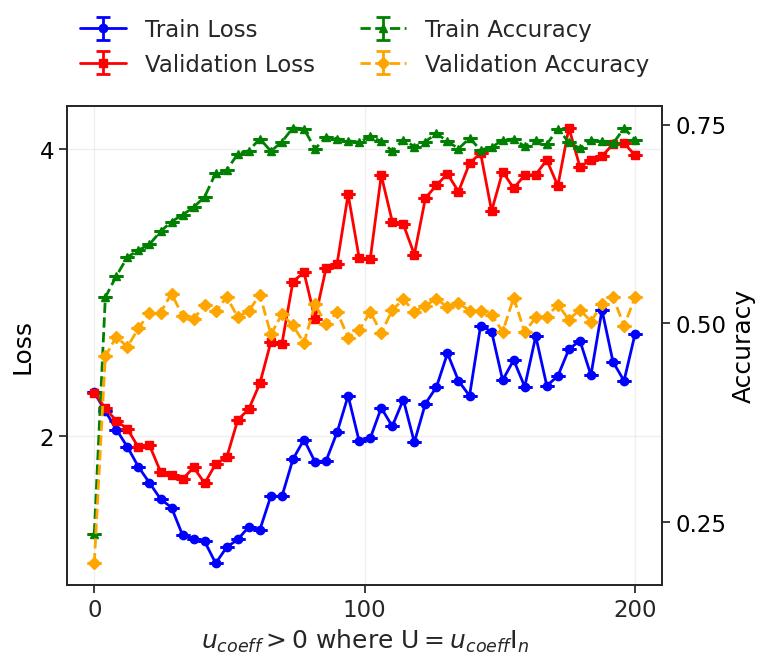

In [ ]:
# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 7))
ax2 = ax1.twinx()

# Plot losses on the left y-axis
line1 = ax1.errorbar(
    reward_init_values,
    train_means,
    yerr=train_stds,
    label="Train Loss",
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
    color="blue",
)

line2 = ax1.errorbar(
    reward_init_values,
    val_means,
    yerr=val_stds,
    label="Validation Loss",
    marker="s",
    capsize=5,
    capthick=2,
    linewidth=2,
    color="red",
)

# Plot accuracies on the right y-axis
line3 = ax2.errorbar(
    reward_init_values,
    train_accuracy_means,
    yerr=train_accuracy_stds,
    label="Train Accuracy",
    marker="^",
    capsize=5,
    capthick=2,
    linewidth=2,
    color="green",
    linestyle="--",
)

line4 = ax2.errorbar(
    reward_init_values,
    val_accuracy_means,
    yerr=val_accuracy_stds,
    label="Validation Accuracy",
    marker="D",
    capsize=5,
    capthick=2,
    linewidth=2,
    color="orange",
    linestyle="--",
)

# Set labels and colors for axes
ax1.set_xlabel(r"$u_{coeff} > 0$ where $\mathrm{U}=u_{coeff} \mathrm{I}_n$")
ax1.set_ylabel("Loss", color="black")
ax2.set_ylabel("Accuracy", color="black")

# Color the y-axis labels
ax1.tick_params(axis="y", labelcolor="black")
ax2.tick_params(axis="y", labelcolor="black")

# Create combined legend
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(
    lines, labels, frameon=False, bbox_to_anchor=(0.5, 1.02), loc="lower center", ncol=2
)

# Add grid
ax1.grid(True, alpha=0.3)

# Limit the number of ticks
ax1.locator_params(axis="x", nbins=3)
ax1.locator_params(axis="y", nbins=3)
ax2.locator_params(axis="y", nbins=3)

plt.tight_layout()
plt.show()

In [7]:
reward_init_values

[np.float64(0.0001),
 np.float64(0.20417959183673468),
 np.float64(0.40825918367346936),
 np.float64(0.6123387755102041),
 np.float64(0.8164183673469387),
 np.float64(1.0204979591836734),
 np.float64(1.2245775510204082),
 np.float64(1.4286571428571428),
 np.float64(1.6327367346938775),
 np.float64(1.836816326530612),
 np.float64(2.040895918367347),
 np.float64(2.244975510204082),
 np.float64(2.4490551020408167),
 np.float64(2.653134693877551),
 np.float64(2.857214285714286),
 np.float64(3.0612938775510203),
 np.float64(3.265373469387755),
 np.float64(3.46945306122449),
 np.float64(3.6735326530612245),
 np.float64(3.8776122448979593),
 np.float64(4.081691836734693),
 np.float64(4.285771428571429),
 np.float64(4.489851020408163),
 np.float64(4.693930612244897),
 np.float64(4.898010204081633),
 np.float64(5.102089795918367),
 np.float64(5.3061693877551015),
 np.float64(5.510248979591836),
 np.float64(5.714328571428571),
 np.float64(5.918408163265306),
 np.float64(6.12248775510204),
 np.fl

/tmp/ipykernel_828263/2096663248.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_828263/2096663248.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


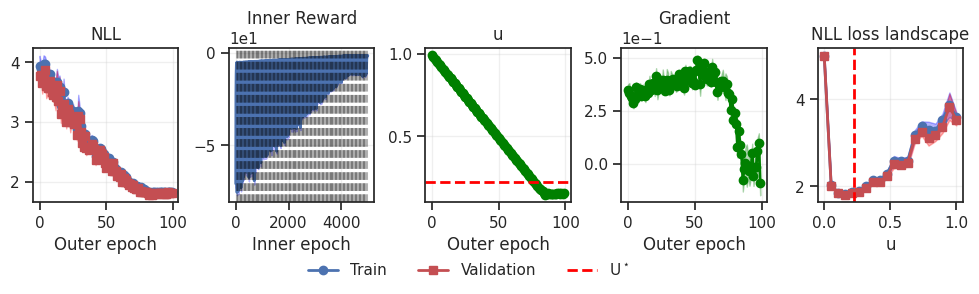

In [ ]:
# Plot results with error bars
fig, ((ax1, ax2, ax3, ax4, ax5)) = plt.subplots(
    1, 5, figsize=(12, 2), gridspec_kw={"wspace": 0.35}
)

# Plot outer losses (train and validation)
epochs_outer = range(len(outer_losses_mean))
ax1.plot(
    epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.plot(
    epochs_outer,
    val_outer_losses_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
ax1.fill_between(
    epochs_outer,
    val_outer_losses_mean - val_outer_losses_se,
    val_outer_losses_mean + val_outer_losses_se,
    alpha=0.3,
    color="red",
)

ax1.set_xlabel("Outer epoch")
ax1.set_title("NLL")
# ax1.set_title("Outer Loss (NLL)")
# ax1.legend()
ax1.grid(True, alpha=0.3)

ax1.locator_params(axis="x", nbins=3)
ax1.locator_params(axis="y", nbins=3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    if i * n_inner_epochs < len(epochs_inner):
        ax2.axvline(
            x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3
        )

ax2.set_xlabel("Inner epoch")
ax2.set_title("Inner Reward")
# ax2.set_title("Inner Rewards")
ax2.grid(True, alpha=0.3)
# Set integer ticks for x-axis
# ax2.set_xticks(range(0, len(epochs_inner), max(1, len(epochs_inner)//10)))

ax2.locator_params(axis="x", nbins=3)
ax2.locator_params(axis="y", nbins=3)

ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Define colors from seaborn default palette
palette = sns.color_palette()  # seaborn default ("deep")
n_params = max(4, len(U_coeff_mean))
colors = [palette[j % len(palette)] for j in range(n_params)]

# Plot U coefficient
for i, (k, v) in enumerate(U_coeff_mean.items()):
    epochs_U = range(len(v))
    color = "green"  # colors[i % len(colors)]
    if reward_use_softplus:
        ax3.plot(
            epochs_U,
            np.log(1 + np.exp(v)),
            "-o",
            linewidth=2,
            markersize=6,
            # label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U,
            np.log(1 + np.exp(v - U_coeff_se[k])),
            np.log(1 + np.exp(v + U_coeff_se[k])),
            alpha=0.3,
            color=color,
        )
    else:
        ax3.plot(
            epochs_U,
            v,
            "-o",
            linewidth=2,
            markersize=6,
            # label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U, v - U_coeff_se[k], v + U_coeff_se[k], alpha=0.3, color=color
        )
# if U_star is not None:
#     ax3.axhline(
#         y=U_star, color="red", linestyle="--", linewidth=2, label=r"$\mathrm{U}^\star$"
#     )
# if U_hat_star is not None:
#     ax3.axhline(
#         y=U_hat_star, color="gray", linestyle="--", linewidth=2, label=r"$\hat{\mathrm{U}}^\star$"
#     )
ax3.set_xlabel("Outer epoch")
ax3.set_title(r"$\mathrm{u}$")
# ax3.set_title("Reward Network Parameter")
# ax3.legend()
ax3.grid(True, alpha=0.3)

ax3.locator_params(axis="x", nbins=3)
ax3.locator_params(axis="y", nbins=3)

# Plot U coefficient gradients
for i, (k, v) in enumerate(U_coeff_grad_mean.items()):
    color = "green"  # colors[i % len(colors)]
    epochs_U = range(len(v))
    ax4.plot(
        epochs_U,
        v,
        "-o",
        linewidth=2,
        markersize=6,
        label=k if len(U_coeff_grad_mean) <= 4 else None,
        color=color,
    )
    ax4.fill_between(
        epochs_U, v - U_coeff_grad_se[k], v + U_coeff_grad_se[k], alpha=0.3, color=color
    )
ax4.set_xlabel("Outer epoch")
ax4.set_title("Gradient")
# ax4.set_title("U_coeff Gradient (clipped at [-10,10])")
ax4.grid(True, alpha=0.3)

ax4.locator_params(axis="x", nbins=3)
ax4.locator_params(axis="y", nbins=3)

# Set y-axis to scientific notation for ax5
ax4.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))


ax5.plot(
    reward_init_values,
    train_means,
    "b-o",
    linewidth=2,
    markersize=6,
    label="Train",
)
ax5.fill_between(
    reward_init_values,
    np.array(train_means) - np.array(train_stds),
    np.array(train_means) + np.array(train_stds),
    alpha=0.3,
    color="blue",
)
ax5.plot(
    reward_init_values,
    val_means,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
ax5.fill_between(
    reward_init_values,
    np.array(val_means) - np.array(val_stds),
    np.array(val_means) + np.array(val_stds),
    alpha=0.3,
    color="red",
)

# # Plot train loss with error bars
# ax5.errorbar(
#     reward_init_values,
#     train_means,
#     yerr=train_stds,
#     label="Train Loss",
#     marker="o",
#     capsize=5,
#     capthick=2,
#     linewidth=2,
#     color=colors[0],
# )

# # Plot validation loss with error bars
# ax5.errorbar(
#     reward_init_values,
#     val_means,
#     yerr=val_stds,
#     label="Validation Loss",
#     marker="s",
#     capsize=5,
#     capthick=2,
#     linewidth=2,
#     color=colors[2],
# )

# Add vertical line at U_star (apply softplus if needed)
# ax5.axvline(
#     x=U_star,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label=r"$\mathrm{U}^\star$",
# )

ax5.set_xlabel(r"$\mathrm{u}$")
ax5.set_title("NLL loss landscape")
# plt.title("Loss Landscape vs Reward Parameter")
ax5.legend(frameon=False, bbox_to_anchor=(-2.4, -0.58), loc="lower center", ncol=3)
# ax5.legend()
ax5.grid(True, alpha=0.3)

# Limit the number of ticks to 3 in both axes
ax5.locator_params(axis="x", nbins=3)
ax5.locator_params(axis="y", nbins=3)

# suptitle = f"{n_outer_epochs} outer iterations, {n_inner_epochs} inner epochs, {max_repetitions} experiments, "
# suptitle += r"$R(\hat{y},y) = -(\hat{y}-y)^\top u_{coeff} \mathrm{I}_n (\hat{y}-y)$"

# fig.suptitle(
#     suptitle,
#     fontsize=16,
#     y=0.98,
# )
fig.tight_layout()
plt.tight_layout()
plt.savefig("../figures/implicit_all_fig.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
sns.set_style("ticks")